<a href="https://colab.research.google.com/github/shalu-rani2005/Dissertation-/blob/main/Yield_Curve_Inversion_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yield Curve Inversion Analysis - Recession Early Warning Indicator

## Objective
This project analyzes the historical relationship between the U.S. Treasury yield curve (10-year and 3-month yields) and economic recessions. The goal is to examine whether yield curve inversions when short term yields exceed long term yields - have historically served as a reliable early warning signal for recessions, and to evaluate this pattern using 45+ years of historical data (1981-2026).

## Dataset
- **Source:** FRED (Federal Reserve Economic Data), St. Louis Federal Reserve
- **Series used:** DGS10 (10-Year Treasury Yield), DGS3MO (3-Month Treasury Yield)
- **Time period:** 1981-2026 (daily data)

## Tools Used
Python, Pandas, Matplotlib

## Step 1 : Connect Google Drive to Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 : Import Libraries and Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_10yr = pd.read_csv('/content/drive/MyDrive/Time Series Analysis/Projects/Project_dataset/DGS10.csv')
df_3mo = pd.read_csv('/content/drive/MyDrive/Time Series Analysis/Projects/Project_dataset/DGS3MO.csv')

In [5]:
print(df_10yr.head())
print(df_3mo.head())

  observation_date  DGS10
0       1962-01-02   4.06
1       1962-01-03   4.03
2       1962-01-04   3.99
3       1962-01-05   4.02
4       1962-01-08   4.03
  observation_date  DGS3MO
0       1981-09-01   17.01
1       1981-09-02   16.65
2       1981-09-03   16.96
3       1981-09-04   16.64
4       1981-09-07     NaN


In [6]:
print(df_10yr.columns)
print(df_3mo.columns)

Index(['observation_date', 'DGS10'], dtype='object')
Index(['observation_date', 'DGS3MO'], dtype='object')


## Step 3 : Convert observation_date to a datetime and set as index

In [7]:
df_10yr['observation_date'] = pd.to_datetime(df_10yr['observation_date'])
df_3mo['observation_date'] = pd.to_datetime(df_3mo['observation_date'])

df_10yr.set_index('observation_date', inplace=True)
df_3mo.set_index('observation_date', inplace=True)

## Step 4 : Merge 10-year yield data with 3-month yield data

In [8]:
df = pd.merge(df_10yr, df_3mo, on='observation_date', how = 'inner')

In [9]:
print(df.head())
print(df.shape)

                  DGS10  DGS3MO
observation_date               
1981-09-01        15.41   17.01
1981-09-02        15.40   16.65
1981-09-03        15.48   16.96
1981-09-04        15.51   16.64
1981-09-07          NaN     NaN
(11721, 2)


## Step 4 : Data Cleaning

In [10]:
print(df.isnull().sum())

DGS10     490
DGS3MO    491
dtype: int64


In [11]:
df = df.dropna()

In [12]:
print(df.isnull().sum())
print(df.shape)

DGS10     0
DGS3MO    0
dtype: int64
(11230, 2)


## Step 5 : Calculate Yield Spread

In [13]:
df['Spread'] = df['DGS10'] - df['DGS3MO']
print(df.head())

                  DGS10  DGS3MO  Spread
observation_date                       
1981-09-01        15.41   17.01   -1.60
1981-09-02        15.40   16.65   -1.25
1981-09-03        15.48   16.96   -1.48
1981-09-04        15.51   16.64   -1.13
1981-09-08        15.59   16.54   -0.95


## Step 6 : 30-day and 90-day Rolling average of Spread (Smoothing)

In [14]:
df['Spread_MA30'] = df['Spread'].rolling(window=30).mean()
df['Spread_MA90'] = df['Spread'].rolling(window=90).mean()

## Step 7 : Visualizations

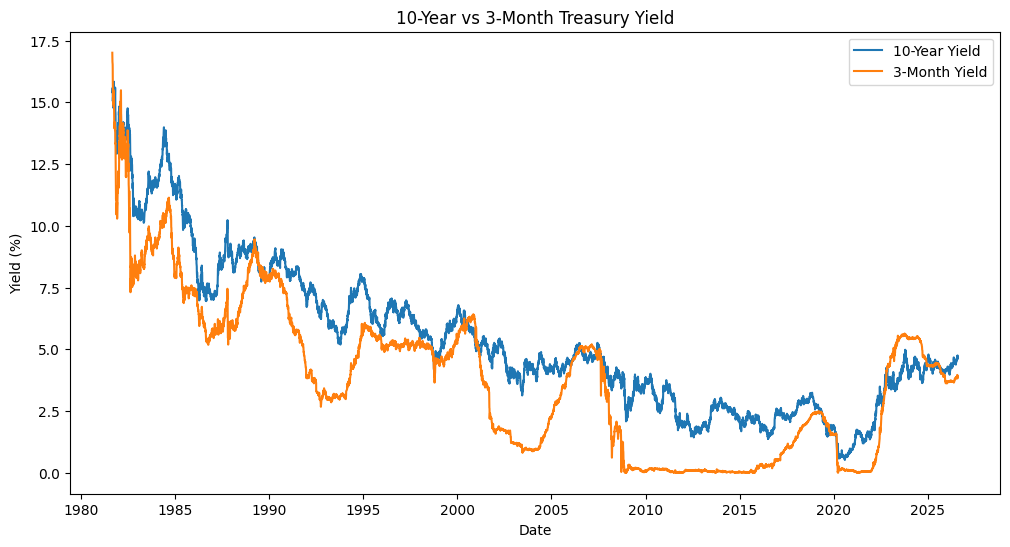

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['DGS10'], label='10-Year Yield')
plt.plot(df.index, df['DGS3MO'], label='3-Month Yield')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.title('10-Year vs 3-Month Treasury Yield')
plt.legend()
plt.show()

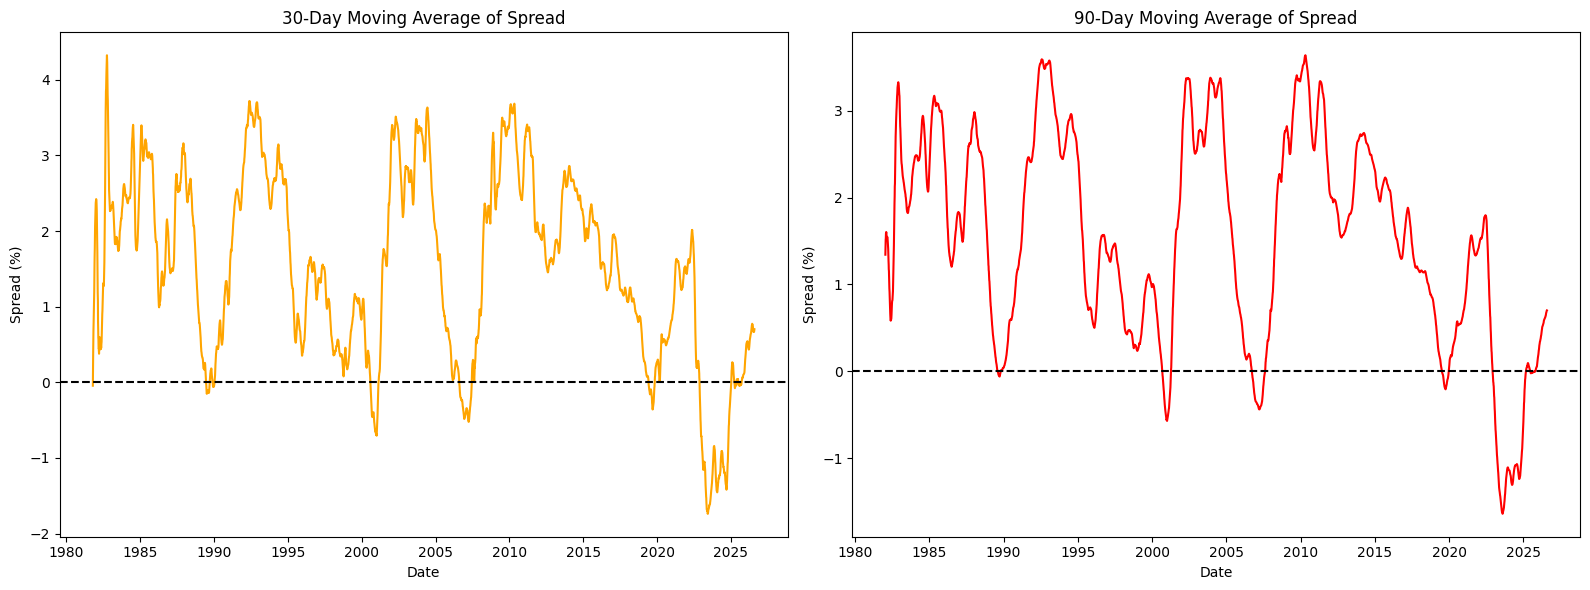

In [16]:
fig,axes = plt.subplots(1,2,figsize = (16,6))

# 30-day MA of Spread
axes[0].plot(df.index, df['Spread_MA30'], color='orange')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('30-Day Moving Average of Spread')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Spread (%)')

# 90-day MA of Spread
axes[1].plot(df.index, df['Spread_MA90'], color='red')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('90-Day Moving Average of Spread')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Spread (%)')

plt.tight_layout()
plt.show()

## Step 7 : Pattern Analysis (Inversions vs Recessions)

In [17]:
inverted_days = df[df['Spread_MA90'] < 0]
print(inverted_days['Spread_MA90'])
print(inverted_days.shape)

observation_date
1989-08-09   -0.001778
1989-08-10   -0.003333
1989-08-11   -0.005000
1989-08-14   -0.006222
1989-08-15   -0.009000
                ...   
2025-10-14   -0.000222
2025-10-16   -0.000778
2025-10-17   -0.001111
2025-10-20   -0.001000
2025-10-21   -0.000333
Name: Spread_MA90, Length: 1176, dtype: float64
(1176, 5)


In [18]:
print(inverted_days.index.min())
print(inverted_days.index.max())

1989-08-09 00:00:00
2025-10-21 00:00:00


In [19]:
inverted_days.index.year.value_counts().sort_index()

,count
observation_date,
1989,49
2000,78
2001,69
2006,69
2007,155
2019,115
2022,16
2023,250
2024,250


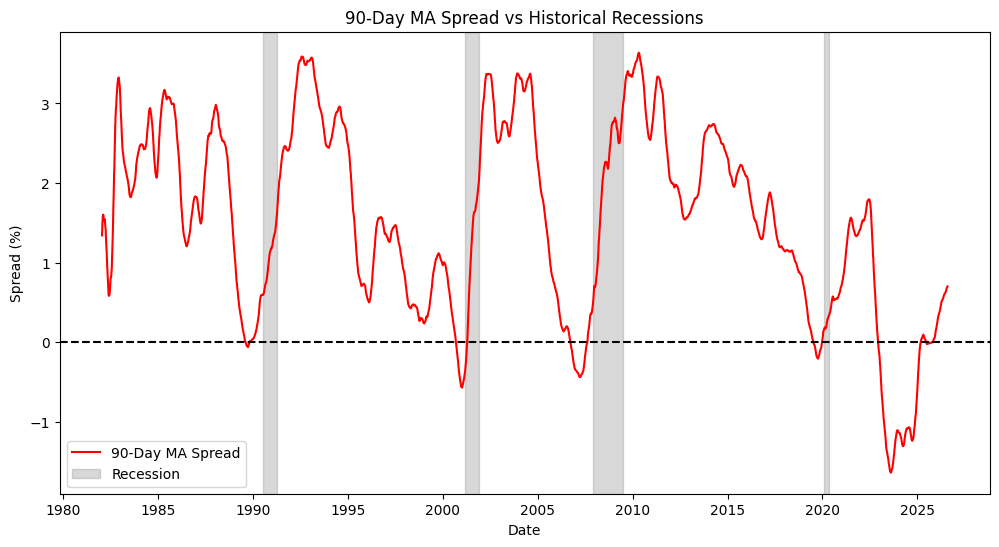

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Spread_MA90'], color='red', label='90-Day MA Spread')
plt.axhline(0, color='black', linestyle='--')

plt.axvspan('1990-07-01', '1991-03-31', color='gray', alpha=0.3, label='Recession')
plt.axvspan('2001-03-01', '2001-11-30', color='gray', alpha=0.3)
plt.axvspan('2007-12-01', '2009-06-30', color='gray', alpha=0.3)
plt.axvspan('2020-02-01', '2020-04-30', color='gray', alpha=0.3)

plt.xlabel('Date')
plt.ylabel('Spread (%)')
plt.title('90-Day MA Spread vs Historical Recessions')
plt.legend()
plt.show()

In [21]:
print("1989:", inverted_days.loc['1989'].index.min(), "to", inverted_days.loc['1989'].index.max())

print("2000:", inverted_days.loc['2000'].index.min(), "to", inverted_days.loc['2000'].index.max())

print("2006-07:", inverted_days.loc['2006':'2007'].index.min(), "to", inverted_days.loc['2006':'2007'].index.max())

print("2019:", inverted_days.loc['2019'].index.min(), "to", inverted_days.loc['2019'].index.max())

print("2022-25:", inverted_days.loc['2022':'2025'].index.min(), "to", inverted_days.loc['2022':'2025'].index.max())

1989: 1989-08-09 00:00:00 to 1989-10-18 00:00:00
2000: 2000-09-08 00:00:00 to 2000-12-29 00:00:00
2006-07: 2006-09-21 00:00:00 to 2007-08-10 00:00:00
2019: 2019-07-10 00:00:00 to 2019-12-23 00:00:00
2022-25: 2022-12-08 00:00:00 to 2025-10-21 00:00:00


## Conclusion and Insights

### Key Findings:

1. **Yield curve inversion** (when the 3-month Treasury yield exceeds the 10-year yield) has historically served as a reliable recession warning signal.

2. **Historical pattern (1989-2019):** Every major inversion period was followed by an official U.S. recession within 2-9 months:
| **Inversion Period** | **Recession** | **Gap (months)** |
| --- | --- | --- |
| 1989 | 1990-91 | ~9 |
| 2000 | 2001 | ~3 |
| 2006-07 | 2008 | ~4 |
| 2019 | 2020 | ~2 |
| 2022-25 | Not yet occurred | - |

3. **The 2022-2025 case is unique:** This was the longest inversion period on record (~3 years, Dec 2022 - Oct  2025), compared to previous inversions which lasted only a few months to about a year. Despite this, no official recession has occurred yet (based on available data) - a deviation from the historical pattern.

4. **Possible explanations:**
- The Fed's aggressive rate hikes (2022-23) may have controlled inflation without pushing the economy into a full recession (a "soft landing").
- The recession may simply be delayed and still forthcoming.
- The yield curve may be giving a false signal this time - no indicator is 100% accurate.

### Limitations:
- This analysis shows correlation only, not causation - yield curve      inversion does not "cause" recessions, it is merely a warning signal
- Only 4 historical cases are available for comparison, which is a statistically small sample size
- Recession dates were taken from official NBER records for reference, not calculated within this analysis